# Singular Isothermal Sphere host: comparison with Benson+Du22

Reproduction of the Benson+Du22 second-order tidal heating result on SatGen, matching their setup as closely as possible. Host is a Singular Isothermal Sphere ($\rho \propto r^{-2}$, flat rotation curve) — same profile Benson, Du, Errani, and Navarro use for the canonical tidal-track comparison. This is the primary Benson+Du22 reproduction; the cross-checks against SatGen's built-in prescriptions live in `stripping_nfw.ipynb` (Milky-Way NFW host vs the DASH/Green transfer function) and `stripping.ipynb` (which highlights the over-stripping artefact in SatGen's reshape-after-each-step P10/Dekel pattern from `SatEvo.py`).

- host: Singular Isothermal Sphere, $M_{\rm vir} = 3.7 \times 10^{12}\,M_\odot$ ($V_c \approx 224$ km/s)
- subhalo: NFW, $r_s = 0.22$ kpc, $M(<r_{\max}) = 10^6\,M_\odot$ $\to$ $r_{\max} = 0.48$ kpc, $v_{\max} = 3.0$ km/s, truncated at $10\,r_s$
- orbit: apocenter 200 kpc, $V_{\rm tan} = 50$ km/s $\to$ $r_p/r_a \approx 0.10$ (one of Benson+Du22's three calibration orbits)
- heating: $\gamma_h = 1.5$ (slow shocks), $f_2 = 0.406$, $\chi_v = -0.333$ — all Benson+Du22 calibration values
- adiabatic correction: $\omega_p$ at the subhalo half-mass radius, $T_{\rm shock} = r/V$ (Pullen+14 / Gnedin+99)

Reference track is the Errani & Navarro 2021 fitting function (Benson+Du22 eq. 1).

In [1]:
import numpy as np
import time

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import config as cfg
from profiles import NFW, Dekel
from subhalo_functions import SIS, NumericProfile
import stripping_common as sc

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


In [2]:
cfg.Mres = 1e1

# host
Mv = 3.7e12

# Benson+Du22 subhalo: NFW with M(<r_max) = 1e6 Msun and r_s = 0.22 kpc,
# exponentially truncated at 10 r_s. Benson+Du22 specify the mass *within
# r_max*, not M_vir, so we can't pick (M_vir, c) freely — solve for the
# concentration that gives the right (r_s, M(<r_max)) pair.
from scipy.optimize import brentq
rs_target  = 0.22
M_in_rmax  = 1e6
mu_at_rmax = np.log(1. + 2.163) - 2.163 / (1. + 2.163)         # NFW M(<r_max)/M_vir factor

def _err(c):
    mu_c  = np.log(1. + c) - c / (1. + c)
    M_vir = M_in_rmax * mu_c / mu_at_rmax
    return NFW(M_vir, c).rs - rs_target

cNFW_sub = brentq(_err, 1., 100.)
mu_c     = np.log(1. + cNFW_sub) - cNFW_sub / (1. + cNFW_sub)
mv0      = M_in_rmax * mu_c / mu_at_rmax
sat_nfw  = NFW(mv0, cNFW_sub)

# truncate at 10 r_s (Benson+Du22). sat_nfw.rh would be the full virial
# radius, which lies beyond 10 r_s for this concentration.
r_trunc_sub = 10. * sat_nfw.rs
rvals       = np.logspace(np.log10(cfg.Rres), np.log10(r_trunc_sub), 100)
M_sub_arr   = sat_nfw.M(rvals)
M_tot_sub   = M_sub_arr[-1]

# heating: Benson+Du22 use gamma=1.5 (slow shocks); eps_h=3 from Pullen+14
epsh   = 3.
gamma  = 1.5
Nstep  = 30000
tmax   = 30.

hSIS = SIS(Mv)

# Benson+Du22 orbit: apocenter R0 = 200 kpc, V_tan = 50 km/s -> r_p/r_a ~ 0.10
R0       = 200.
eta_bd22 = (50. / 1.022) / hSIS.Vc                             # 50 km/s in kpc/Gyr / Vc
xv0, _   = sc.make_orbit(hSIS, R0=R0, z0=0., eta=eta_bd22)

from profiles import tdyn as _tdyn
dt = tmax / Nstep
print(f"Host SIS : rh={hSIS.rh:.1f} kpc, Vc={hSIS.Vc:.1f} kpc/Gyr ({hSIS.Vc/1.022:.0f} km/s)")
print(f"Sub  NFW : Mvir={mv0:.2e} Msun, c={cNFW_sub:.2f}, "
      f"rs={sat_nfw.rs:.3f} kpc, rmax={sat_nfw.rmax:.3f} kpc, "
      f"Vmax={sat_nfw.Vmax:.3f} kpc/Gyr ({sat_nfw.Vmax/1.022:.2f} km/s)")
print(f"           rtrunc=10*rs={r_trunc_sub:.2f} kpc, M(<rtrunc)={M_tot_sub:.2e} Msun")
print(f"Orbit    : R0={R0:.0f} kpc, Vphi={xv0[4]:.2f} kpc/Gyr "
      f"({xv0[4]/1.022:.1f} km/s), eta={eta_bd22:.3f}")
print(f"dt={dt:.5f} Gyr, t_dyn(R0)={_tdyn(hSIS, R0):.4f} Gyr, "
      f"dt/t_dyn={dt/_tdyn(hSIS,R0):.3f}")

Host SIS : rh=319.1 kpc, Vc=228.4 kpc/Gyr (223 km/s)
Sub  NFW : Mvir=3.89e+06 Msun, c=14.75, rs=0.220 kpc, rmax=0.476 kpc, Vmax=3.075 kpc/Gyr (3.01 km/s)
           rtrunc=10*rs=2.20 kpc, M(<rtrunc)=3.18e+06 Msun
Orbit    : R0=200 kpc, Vphi=48.92 kpc/Gyr (47.9 km/s), eta=0.214
dt=0.00100 Gyr, t_dyn(R0)=1.3755 Gyr, dt/t_dyn=0.001


In [3]:
# verify pericentre / apocenter
from orbit import orbit as _orb
t_check = np.linspace(0., 4., 4000)
_o = _orb(xv0)
_o.integrate(t_check, hSIS)
r_check = np.sqrt(_o.xvArray[:,0]**2 + _o.xvArray[:,2]**2)
print(f"r_peri = {r_check.min():.1f} kpc  r_apo = {r_check.max():.1f} kpc  r_p/r_a = {r_check.min()/r_check.max():.3f}")
print(f"(Benson+Du22: r_peri ~ 25 kpc, r_apo = 200 kpc, r_p/r_a ~ 0.10-0.13)")

r_peri = 19.8 kpc  r_apo = 200.0 kpc  r_p/r_a = 0.099
(Benson+Du22: r_peri ~ 25 kpc, r_apo = 200 kpc, r_p/r_a ~ 0.10-0.13)


## First-order tidal heating

In [4]:
t0 = time.time()
result_heat = sc.evolve_heating(
    hSIS, NumericProfile(rvals, M_sub_arr), xv0,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma,
    second_order=False,
)
print(f"1st-order: {time.time()-t0:.1f} s")
print(f"  rmax0={result_heat.rmax0:.3f} kpc, vmax0={result_heat.vmax0:.3f} kpc/Gyr "
      f"({result_heat.vmax0/1.022:.2f} km/s)")
print(f"  final m/M_tot = {result_heat.m[result_heat.m>0][-1]/M_tot_sub:.3e}")

1st-order: 73.6 s
  rmax0=0.476 kpc, vmax0=3.075 kpc/Gyr (3.01 km/s)
  final m/M_tot = 7.808e-03


## Second-order tidal heating (Benson+Du22)

In [5]:
t0 = time.time()
result_heat2 = sc.evolve_heating(
    hSIS, NumericProfile(rvals, M_sub_arr), xv0,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma,
    second_order=True,
)
print(f"2nd-order: {time.time()-t0:.1f} s")
print(f"  rmax0={result_heat2.rmax0:.3f} kpc, vmax0={result_heat2.vmax0:.3f} kpc/Gyr "
      f"({result_heat2.vmax0/1.022:.2f} km/s)")
print(f"  final m/M_tot = {result_heat2.m[result_heat2.m>0][-1]/M_tot_sub:.3e}")

2nd-order: 111.5 s
  rmax0=0.476 kpc, vmax0=3.075 kpc/Gyr (3.01 km/s)
  final m/M_tot = 1.833e-04


In [6]:
def en21(x, alpha=0.40, beta=0.65):
    """Errani & Navarro 2021 eq.1 universal NFW tidal track."""
    return 2**alpha * x**beta * (1.0 + x**2)**(-alpha)

x_ref = np.logspace(-2, 0, 400)
y_ref = en21(x_ref)

## Tidal track vs Errani & Navarro 2021

Second-order tidal track follows Errani+Navarro 2021 with median ratio ~1.03. First-order alone sits ~1.5× above — same qualitative behaviour as Benson+Du22 Fig. 1.

Benson+Du22 eq. (4) is a per-shock formula: $\Delta\varepsilon_1$ and $\sigma_r^2$ are quantities accumulated over one full orbit. The square root doesn't split linearly across timesteps — a naive $\sum_i \sqrt{\Delta\varepsilon_{1,i}\,\sigma_r^2}$ scales as $\sqrt{N_{\rm step}}$ instead of $\sqrt{1}$. We track a running cumulant $H(t) = \int \dot{H}\,dt'$ from one pericentre to the next and inject

$$d(\Delta\varepsilon_2)(r) = c_2\,r\,\sqrt{\sigma_r^2(r)}\,\bigl[\sqrt{H(t_i)} - \sqrt{H(t_{i-1})}\bigr]$$

per step. Adjacent steps share the inner sqrt term with opposite signs so the per-step increments add up over a peri-to-peri segment to the per-orbit Benson+Du22 kick exactly. $H$ resets at each pericentre detection, with a $4\,t_{\rm dyn}$ fallback for near-circular orbits.

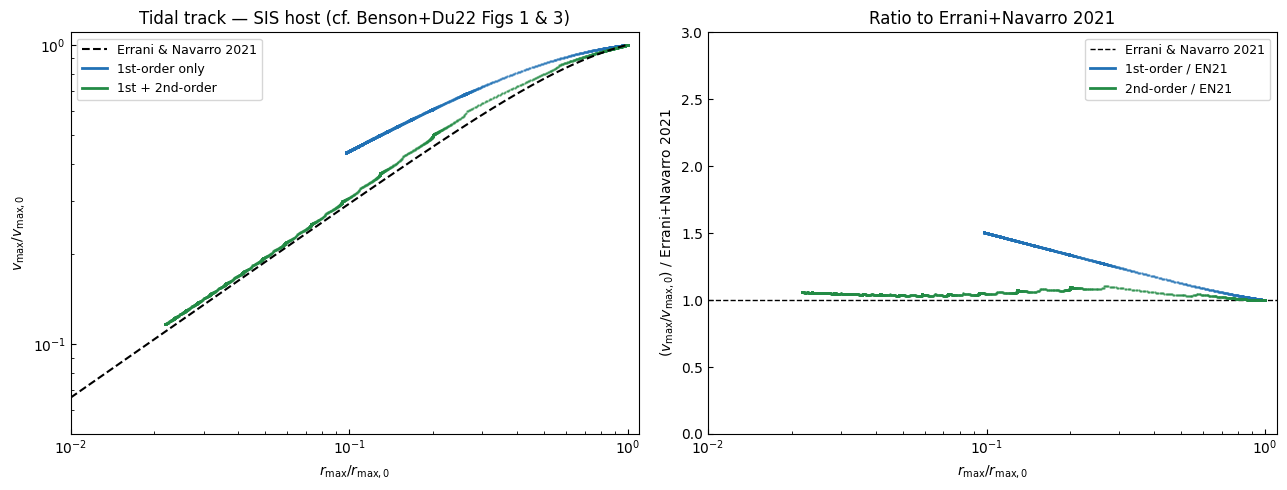

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_ref, y_ref, 'k--', lw=1.5, label='Errani & Navarro 2021', zorder=5)
for res, col, lbl in [
    (result_heat,  '#2171b5', '1st-order only'),
    (result_heat2, '#238b45', '1st + 2nd-order'),
]:
    # mask: drop NaN rmax slots (no interior Vc peak) + NaN-init skipped slots
    mask = np.isfinite(res.rmax) & np.isfinite(res.vmax)
    ax.plot(res.rmax[mask]/res.rmax0, res.vmax[mask]/res.vmax0,
            '.', color=col, ms=1.5, alpha=0.6, label=lbl)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.01, 1.1); ax.set_ylim(0.05, 1.1)
ax.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
ax.set_ylabel(r'$v_{\rm max}/v_{\rm max,0}$')
ax.set_title('Tidal track — SIS host (cf. Benson+Du22 Figs 1 & 3)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=sc.markers_to_lines(h), labels=l, fontsize=9)

ax = axes[1]
ax.axhline(1., color='k', lw=1, ls='--', label='Errani & Navarro 2021')
for res, col, lbl in [
    (result_heat,  '#2171b5', '1st-order / EN21'),
    (result_heat2, '#238b45', '2nd-order / EN21'),
]:
    mask = np.isfinite(res.rmax) & np.isfinite(res.vmax)
    x = res.rmax[mask] / res.rmax0
    y = res.vmax[mask] / res.vmax0
    mid = (x > 0.01) & (x < 1.)
    ax.plot(x[mid], y[mid] / en21(x[mid]), '.', color=col, ms=1.5, alpha=0.6, label=lbl)
ax.set_xscale('log')
ax.set_xlim(0.01, 1.1)
ax.set_ylim(0, 3)
ax.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
ax.set_ylabel(r'$(v_{\rm max}/v_{\rm max,0})$ / Errani+Navarro 2021')
ax.set_title('Ratio to Errani+Navarro 2021')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=sc.markers_to_lines(h), labels=l, fontsize=9)

plt.tight_layout()
plt.show()

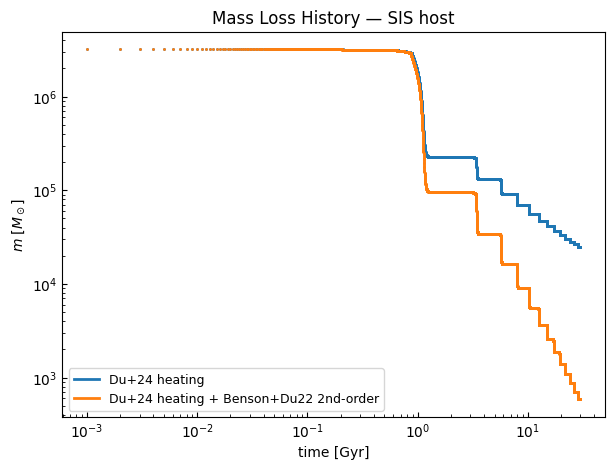

In [8]:
sc.plot_mass_loss([result_heat, result_heat2])
plt.title('Mass Loss History — SIS host')
plt.show()

## Profile evolution snapshots

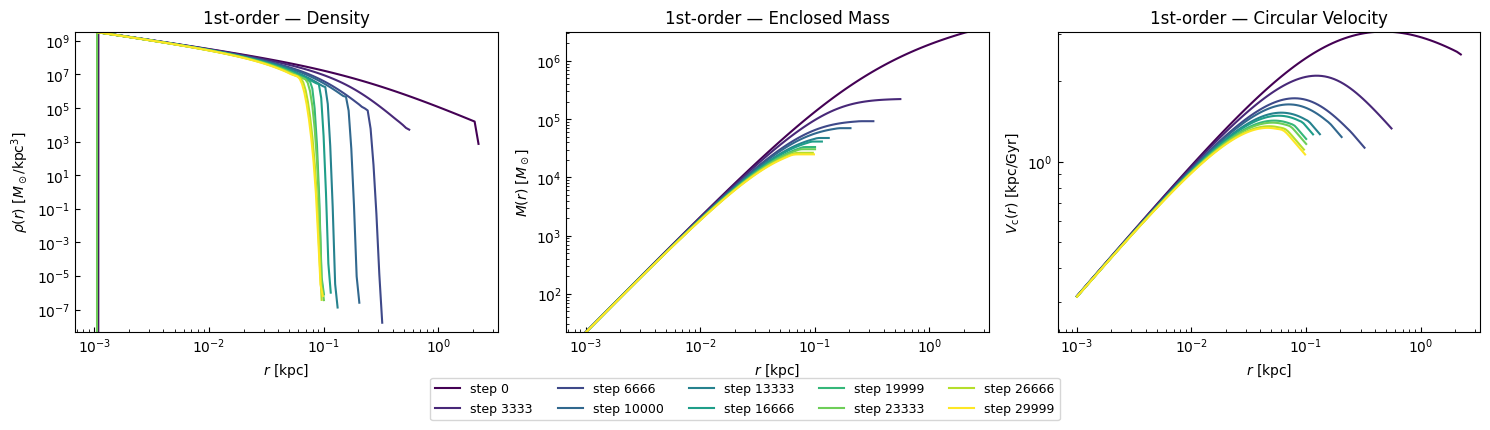

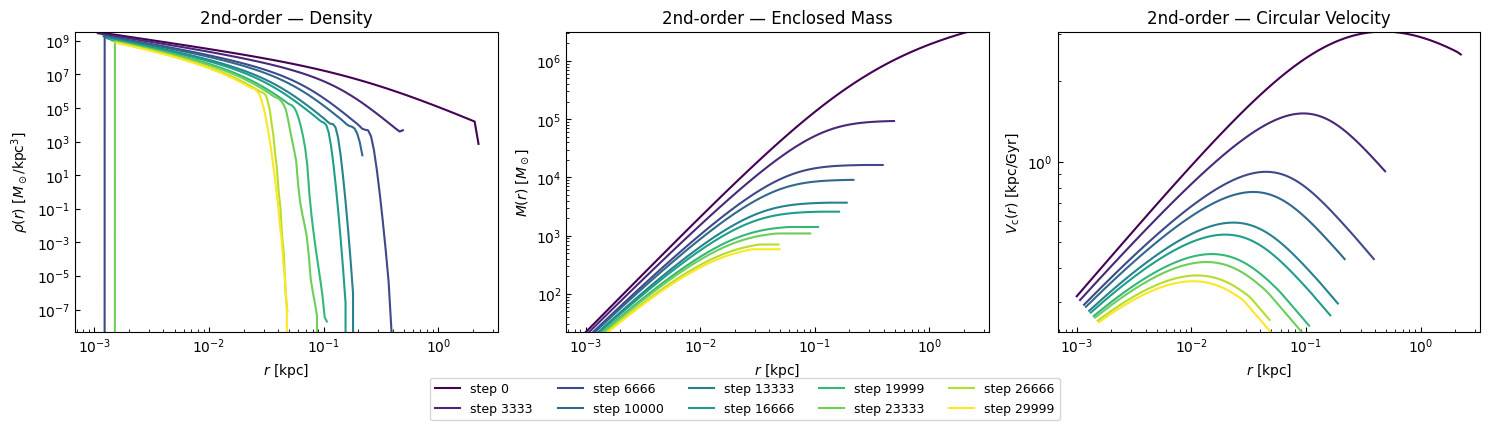

In [9]:
shared_ylims = sc.profile_ylims(result_heat, result_heat2)
for res, prefix in [(result_heat, '1st-order — '), (result_heat2, '2nd-order — ')]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sc.plot_profile_snapshots(res, axes=axes, title_prefix=prefix, ylims=shared_ylims)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc='lower center',
               bbox_to_anchor=(0.5, -0.08), ncol=5)
    plt.tight_layout()
    plt.show()

## Orbital radius

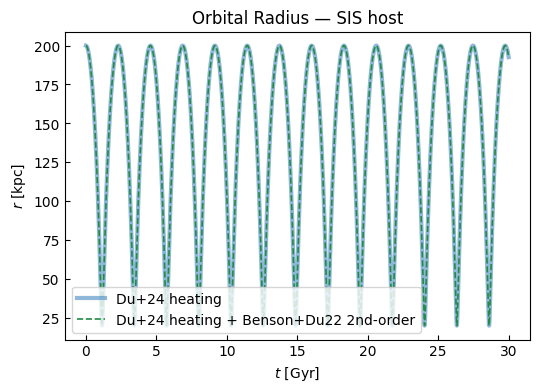

In [10]:
#---thick semi-transparent for 1st-order, thin dashed on top for 2nd-order;
#   the two orbits overlap heavily, so distinct line styles + alpha let both
#   show through wherever they agree
styles = [
    dict(color='#2171b5', linewidth=3.0, alpha=0.5),       # 1st-order
    dict(color='#238b45', linewidth=1.2, linestyle='--'),  # 2nd-order
]
sc.plot_orbit([result_heat, result_heat2], styles=styles)
plt.title('Orbital Radius — SIS host')
plt.show()